In [12]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, plot, iplot

In [13]:
# For Notebooks
init_notebook_mode(connected = True)

In [14]:
# data
df = pd.DataFrame(np.random.randn(100, 4), columns = ["a", "b", "c", "d"])
df.head()

,a,b,c,d
0,-0.992162,1.163647,0.902297,0.701238
1,1.219220,0.154506,-2.834743,0.490275
2,-2.347575,-0.389255,-1.066893,-0.950692
3,0.492821,0.374964,-0.031609,-0.223165
4,1.111261,-0.628832,-2.291514,-0.317736


In [15]:
df2 = pd.DataFrame({"Category": ["a", "b", "c"], "Values": [32, 43, 50]})
df2.head()

,Category,Values
0,a,32
1,b,43
2,c,50


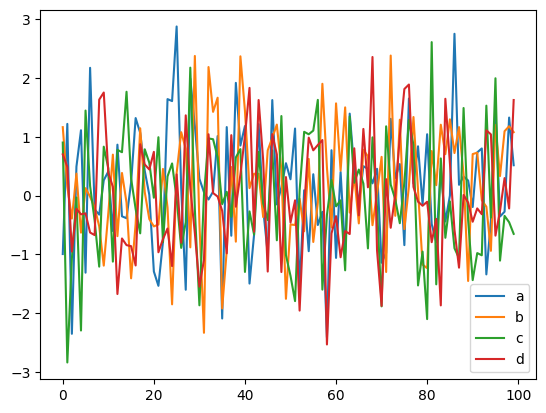

In [16]:
df.plot();

In [17]:
fig = px.line(df, y=df.columns, title="Interactive Line Plot (Plotly Express)")
fig.show()

---------

# Using Cufflinks and iplot()
- scatter
- bar
- box
- spread
- ratio
- heatmap
- surface
- histogram
- bubble

## Scatter

In [19]:
fig = px.scatter(df, x="a", y="b", title="Scatter Plot (a vs b)", opacity=0.8)
fig.update_traces(mode="markers", marker=dict(size=8, color="blue"))
fig.show()


In [25]:
import plotly.express as px

fig = px.scatter(
    df,
    x="a",
    y="b",
    title="Scatter Plot (a vs b)",
    size_max=5  # controls the marker size scale
)
fig.update_traces(marker=dict(size=5, color="orange"))
fig.update_xaxes(dtick=0.5)
fig.show()


## Bar chart

In [31]:
import plotly.express as px

fig = px.bar(df2, x="Category", y="Values", title="Bar Plot")
fig.update_traces(marker_color="#ffb266")
fig.show()


In [28]:
import plotly.graph_objects as go

# Basic colors and example shades (lighter/darker versions)
colors = {
    "Red": ["#ffcccc", "#ff9999", "#ff6666", "#ff3333", "#ff0000"],
    "Green": ["#ccffcc", "#99ff99", "#66ff66", "#33ff33", "#00ff00"],
    "Blue": ["#ccccff", "#9999ff", "#6666ff", "#3333ff", "#0000ff"],
    "Orange": ["#ffe5cc", "#ffcc99", "#ffb266", "#ff9933", "#ff8000"],
    "Purple": ["#f2ccff", "#e599ff", "#d966ff", "#cc33ff", "#b200ff"],
    "Yellow": ["#ffffcc", "#ffff99", "#ffff66", "#ffff33", "#ffff00"],
}

fig = go.Figure()

# Plot each color shade as a bar
for i, (color_name, shades) in enumerate(colors.items()):
    for j, shade in enumerate(shades):
        fig.add_trace(go.Bar(
            x=[1],
            y=[1],
            marker_color=shade,
            name=f"{color_name} {j+1}",
            showlegend=True
        ))

# Layout
fig.update_layout(
    title="Color Shades Example",
    barmode="stack",
    height=600,
    xaxis=dict(showticklabels=False),
    yaxis=dict(showticklabels=False)
)

fig.show()


In [32]:
df.head()

,a,b,c,d
0,-0.992162,1.163647,0.902297,0.701238
1,1.219220,0.154506,-2.834743,0.490275
2,-2.347575,-0.389255,-1.066893,-0.950692
3,0.492821,0.374964,-0.031609,-0.223165
4,1.111261,-0.628832,-2.291514,-0.317736


In [33]:
counts = df.count().reset_index()
counts.columns = ["Column", "Count"]

# Bar plot
fig = px.bar(counts, x="Column", y="Count", title="Count of Non-Null Values per Column",
             text="Count", color="Column")  # optional color by column
fig.show()

In [35]:
sums = df.sum().reset_index()
sums.columns = ["Column", "Sum"]

# Bar plot
fig = px.bar(sums, x="Column", y="Sum", title="Sum of Each Column",
             text="Sum", color="Column")  # optional: color by column
fig.show()

## Boxplot

In [36]:
fig = px.box(df, y=df.columns, points="all",  # show all points
             title="Box Plot of All Columns")
fig.show()

## 3D surface plot

In [37]:
df3 = pd.DataFrame({"x": [1,2,3,4,5], "y": [10,20,30,20,10], "z": [500, 400, 300, 200, 100]})

df3.head()

,x,y,z
0,1,10,500
1,2,20,400
2,3,30,300
3,4,20,200
4,5,10,100


In [39]:
fig = px.imshow(df3.values, color_continuous_scale='RdYlBu', title="Surface Plot")
fig.show()


## Histogram

In [40]:
fig = px.histogram(df, x="a", nbins=50, title="Histogram of Column 'a'",
                   color_discrete_sequence=["orange"])  # optional color
fig.show()

In [34]:
df["a"].iplot(kind = "hist", bins = 50);

In [42]:


# Melt dataframe to long format
df_melted = df.melt(var_name='Column', value_name='Value')

fig = px.histogram(df_melted, x='Value', color='Column', barmode='overlay',
                   nbins=50, title="Histogram of All Columns")
fig.show()


## Spread

In [47]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Sample Data
df = pd.DataFrame(np.random.randn(100, 2), columns=["a", "b"])

# Calculate the spread (difference between columns)
df["spread"] = df["a"] - df["b"]

# Plot using Plotly
fig = go.Figure()

# Original lines
fig.add_trace(go.Scatter(y=df["a"], mode="lines", name="a"))
fig.add_trace(go.Scatter(y=df["b"], mode="lines", name="b"))

# Spread area
fig.add_trace(go.Scatter(
    y=df["spread"],
    mode="lines",
    fill="tozeroy",
    name="Spread (a - b)",
    line=dict(color="orange")
))

fig.update_layout(
    title="Spread Plot (Difference between a and b)",
    xaxis_title="Index",
    yaxis_title="Value",
    template="plotly_white"
)

fig.show()


## Bubble Plot

In [49]:
import pandas as pd
import numpy as np
import plotly.express as px

# Sample Data
df = pd.DataFrame(np.random.randn(100, 3), columns=["a", "b", "c"])

# Make bubble sizes positive
df["c"] = df["c"].abs() * 20  # scale up for visibility

# Bubble Plot
fig = px.scatter(
    df,
    x="a",
    y="b",
    size="c",
    color="c",
    color_continuous_scale="Viridis",
    title="Bubble Plot Example",
    template="plotly_white"
)

fig.show()


## Scatter Matrix Plot

In [43]:
fig = px.scatter_matrix(df,
                        dimensions=df.columns,  # columns to include
                        color=None,            # or specify a column for coloring
                        title="Scatter Matrix of df",
                        width=800,
                        height=800)
fig.show()

In [46]:
import pandas as pd
import numpy as np
import plotly.express as px

# Sample data
df = pd.DataFrame(np.random.randn(100, 4), columns=["a", "b", "c", "d"])

# Scatter matrix plot
fig = px.scatter_matrix(
    df,
    dimensions=["a", "b", "c", "d"],  # columns to include
    color="a",                        # color can be based on one column or category
    title="Scatter Matrix with Histograms",
    width=900,
    height=900
)

# Show histograms on the diagonal
fig.update_traces(diagonal_visible=True)

fig.show()
